In [64]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy
from matplotlib import cm
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER


In [2]:
tmaxUTC = xr.open_dataset("/Projects/era5/Dailies/monolevel/tmax.2m.1941.nc")
tmaxSLD = xr.open_dataset("/Projects/RAPrototype/ERA5/SolarDayTime/tmax.2m.1941.FromSolarDayTime.nc")

In [31]:
FairbanksUTC = tmaxUTC['tmax'].sel(lat=64.8, lon=-147.8+360, method='nearest')
DenverUTC = tmaxUTC['tmax'].sel(lat=39.7, lon=-105.0+360, method='nearest')
SanFranciscoUTC = tmaxUTC['tmax'].sel(lat=37.8, lon=-122.4+360, method='nearest')
ChicagoUTC = tmaxUTC['tmax'].sel(lat=41.8, lon=-87.6+360, method='nearest')
NYCUTC = tmaxUTC['tmax'].sel(lat=40.7, lon=-74.0+360, method='nearest')


FairbanksSLD = tmaxSLD['tmax'].sel(lat=64.8, lon=-147.8+360, method='nearest')
DenverSLD = tmaxSLD['tmax'].sel(lat=39.7, lon=-105.0+360, method='nearest')
SanFranciscoSLD = tmaxSLD['tmax'].sel(lat=37.8, lon=-122.4+360, method='nearest')
ChicagoSLD = tmaxSLD['tmax'].sel(lat=41.8, lon=-87.6+360, method='nearest')
NYCSLD = tmaxSLD['tmax'].sel(lat=40.7, lon=-74.0+360, method='nearest')

In [4]:
CB_color = ['#377eb8', '#ff7f00', '#4daf4a',\
            '#e41a1c', '#a65628', '#984ea3',\
            '#999999', '#f781bf', '#dede00']

In [32]:
UTC = [FairbanksUTC, DenverUTC, SanFranciscoUTC, ChicagoUTC, NYCUTC]
SLD = [FairbanksSLD, DenverSLD, SanFranciscoSLD, ChicagoSLD, NYCSLD]
tip = ['Fairbanks', 'Denver', 'SanFrancisco', 'Chicago', 'NYC' ]

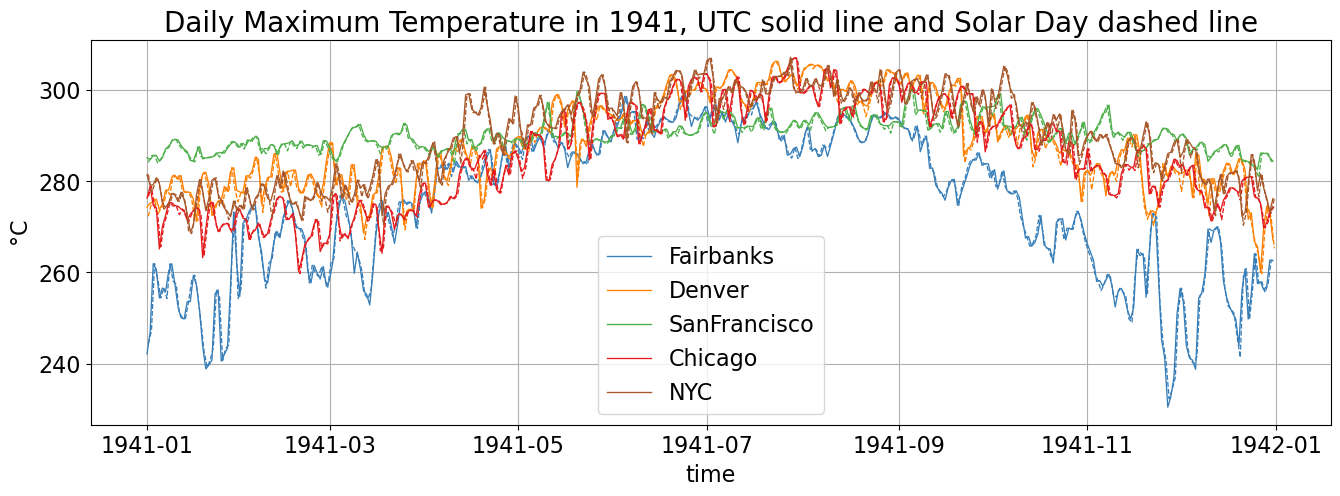

In [59]:
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(16,5))
for ip in range(len(UTC)):
  ax.plot(tmaxUTC['time'],UTC[ip],color=CB_color[ip],linewidth=0.95,label=tip[ip])
  ax.plot(tmaxSLD['time'],SLD[ip],color=CB_color[ip],linewidth=0.95,linestyle='--')
ax.tick_params(labelsize=16)
plt.legend(loc='best',prop={'size': 16})
plt.grid(True)
plt.ylabel(f'$\degree$C',fontsize=16)  
plt.xlabel('time',fontsize=16)
plt.title('Daily Maximum Temperature in 1941, UTC solid line and Solar Day dashed line',fontsize=20)
plt.show()

In [21]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

/tmp/ipykernel_2150457/188399294.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('turbo')


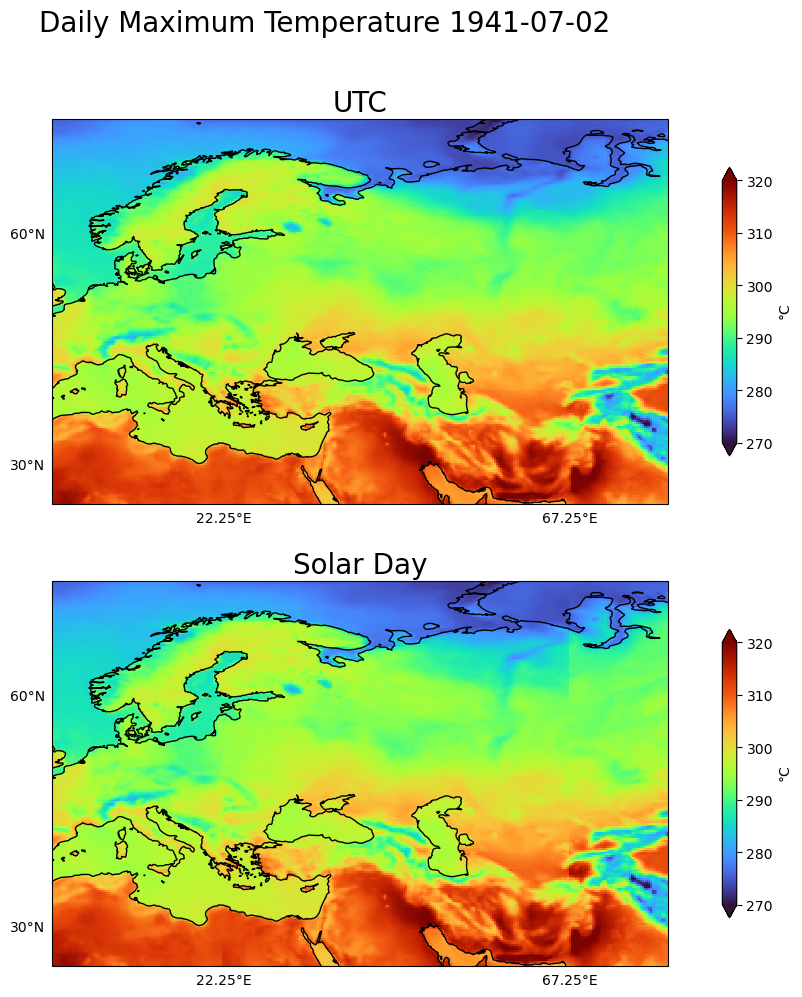

In [74]:
cmap = cm.get_cmap('turbo')
proj=ccrs.PlateCarree(central_longitude=0)

fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(14,11),subplot_kw={'projection':proj})
tmaxUTC['tmax'].isel(time=182).plot.pcolormesh(ax=ax[0],cmap=cmap,transform=proj,cbar_kwargs={'label':'$\degree$C','shrink':0.75},vmin=270,vmax=320) 
tmaxSLD['tmax'].isel(time=182).plot.pcolormesh(ax=ax[1],cmap=cmap,transform=proj,cbar_kwargs={'label':'$\degree$C','shrink':0.75},vmin=270,vmax=320)
gl0 = ax[0].gridlines(draw_labels={"bottom": "x", "left": "y"},  color='gray', alpha=0.001, linestyle='--')
gl1 = ax[1].gridlines(draw_labels={"bottom": "x", "left": "y"},  color='gray', alpha=0.001, linestyle='--')
ax[0].add_feature(cfeature.COASTLINE,edgecolor='black',facecolor='none',zorder=1)
ax[1].add_feature(cfeature.COASTLINE,edgecolor='black',facecolor='none',zorder=1)
ax[0].set_extent([0, 80, 25, 75], crs=ccrs.PlateCarree())
ax[1].set_extent([0, 80, 25, 75], crs=ccrs.PlateCarree())
ax[0].set_title('UTC',fontsize=20)
ax[1].set_title('Solar Day',fontsize=20)
custom_xticks = [0, 22.25, 67.25,112.25,157.25, 180, 202.25,247.25,292.25,337.25,360]
custom_yticks = [-60, -30, 0, 30, 60]

# 3. Apply the locators to the gridliner
gl0.xlocator = mticker.FixedLocator(custom_xticks)
gl0.ylocator = mticker.FixedLocator(custom_yticks)
gl1.xlocator = mticker.FixedLocator(custom_xticks)
gl1.ylocator = mticker.FixedLocator(custom_yticks)

# 4. Apply standard formatters
gl0.xformatter = LONGITUDE_FORMATTER
gl0.yformatter = LATITUDE_FORMATTER
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER
plt.suptitle(f"Daily Maximum Temperature {tmaxUTC['time'][182].dt.strftime('%Y-%m-%d').data}",fontsize=20)
plt.show()

/tmp/ipykernel_2150457/924735740.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('turbo')


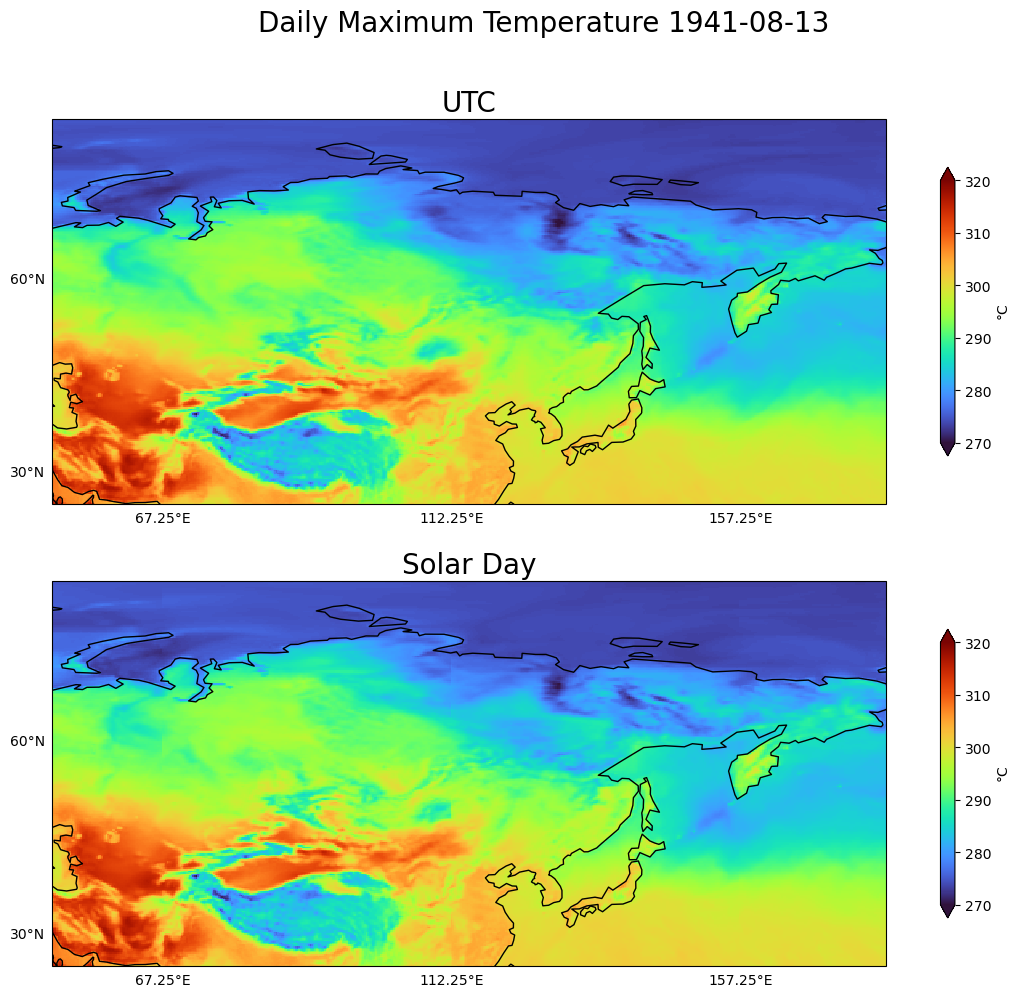

In [78]:
cmap = cm.get_cmap('turbo')
proj=ccrs.PlateCarree(central_longitude=0)

fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(14,11),subplot_kw={'projection':proj})
tmaxUTC['tmax'].isel(time=224).plot.pcolormesh(ax=ax[0],cmap=cmap,transform=proj,cbar_kwargs={'label':'$\degree$C','shrink':0.75},vmin=270,vmax=320) 
tmaxSLD['tmax'].isel(time=224).plot.pcolormesh(ax=ax[1],cmap=cmap,transform=proj,cbar_kwargs={'label':'$\degree$C','shrink':0.75},vmin=270,vmax=320)
gl0 = ax[0].gridlines(draw_labels={"bottom": "x", "left": "y"},  color='gray', alpha=0.001, linestyle='--')
gl1 = ax[1].gridlines(draw_labels={"bottom": "x", "left": "y"},  color='gray', alpha=0.001, linestyle='--')
ax[0].add_feature(cfeature.COASTLINE,edgecolor='black',facecolor='none',zorder=1)
ax[1].add_feature(cfeature.COASTLINE,edgecolor='black',facecolor='none',zorder=1)
ax[0].set_extent([50, 180, 25, 85], crs=ccrs.PlateCarree())
ax[1].set_extent([50, 180, 25, 85], crs=ccrs.PlateCarree())
ax[0].set_title('UTC',fontsize=20)
ax[1].set_title('Solar Day',fontsize=20)
custom_xticks = [0, 22.25, 67.25,112.25,157.25, 180, 202.25,247.25,292.25,337.25,360]
custom_yticks = [-60, -30, 0, 30, 60]

# 3. Apply the locators to the gridliner
gl0.xlocator = mticker.FixedLocator(custom_xticks)
gl0.ylocator = mticker.FixedLocator(custom_yticks)
gl1.xlocator = mticker.FixedLocator(custom_xticks)
gl1.ylocator = mticker.FixedLocator(custom_yticks)

# 4. Apply standard formatters
gl0.xformatter = LONGITUDE_FORMATTER
gl0.yformatter = LATITUDE_FORMATTER
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER
plt.suptitle(f"Daily Maximum Temperature {tmaxUTC['time'][224].dt.strftime('%Y-%m-%d').data}",fontsize=20)
plt.show()

/tmp/ipykernel_2150457/2020615587.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('turbo')


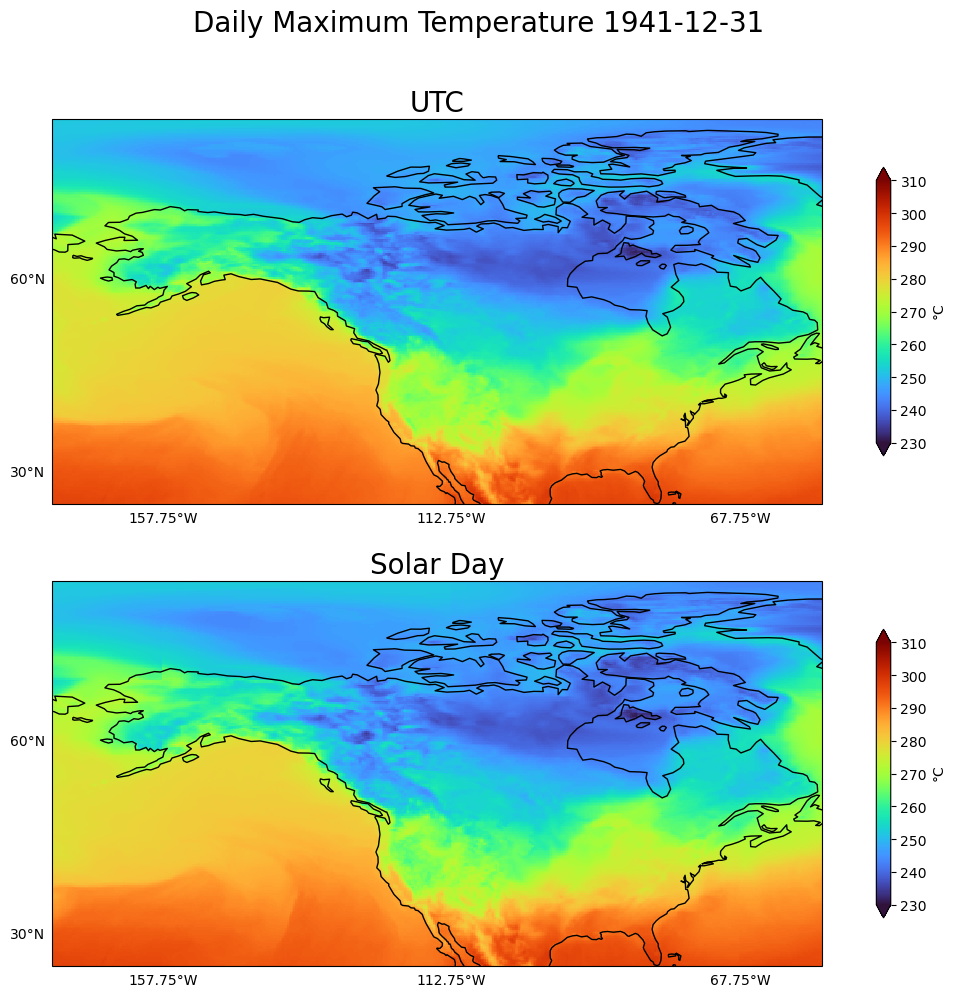

In [87]:
cmap = cm.get_cmap('turbo')
proj=ccrs.PlateCarree(central_longitude=0)

fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(14,11),subplot_kw={'projection':proj})
tmaxUTC['tmax'].isel(time=364).plot.pcolormesh(ax=ax[0],cmap=cmap,transform=proj,cbar_kwargs={'label':'$\degree$C','shrink':0.75},vmin=230,vmax=310) 
tmaxSLD['tmax'].isel(time=364).plot.pcolormesh(ax=ax[1],cmap=cmap,transform=proj,cbar_kwargs={'label':'$\degree$C','shrink':0.75},vmin=230,vmax=310)
gl0 = ax[0].gridlines(draw_labels={"bottom": "x", "left": "y"},  color='gray', alpha=0.001, linestyle='--')
gl1 = ax[1].gridlines(draw_labels={"bottom": "x", "left": "y"},  color='gray', alpha=0.001, linestyle='--')
ax[0].add_feature(cfeature.COASTLINE,edgecolor='black',facecolor='none',zorder=1)
ax[1].add_feature(cfeature.COASTLINE,edgecolor='black',facecolor='none',zorder=1)
ax[0].set_extent([185, 305, 25, 85], crs=ccrs.PlateCarree())
ax[1].set_extent([185, 305, 25, 85], crs=ccrs.PlateCarree())
ax[0].set_title('UTC',fontsize=20)
ax[1].set_title('Solar Day',fontsize=20)
custom_xticks = [202.25-360,247.25-360,292.25-360,337.25-360,360-360]
custom_yticks = [-60, -30, 0, 30, 60]

# 3. Apply the locators to the gridliner
gl0.xlocator = mticker.FixedLocator(custom_xticks)
gl0.ylocator = mticker.FixedLocator(custom_yticks)
gl1.xlocator = mticker.FixedLocator(custom_xticks)
gl1.ylocator = mticker.FixedLocator(custom_yticks)

# 4. Apply standard formatters
gl0.xformatter = LONGITUDE_FORMATTER
gl0.yformatter = LATITUDE_FORMATTER
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER
plt.suptitle(f"Daily Maximum Temperature {tmaxUTC['time'][364].dt.strftime('%Y-%m-%d').data}",fontsize=20)
plt.show()